# Simulation of a positron-induced Muon Source

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


<center>
    <img src="Feynman_Diagram.svg" width="400" style="filter: invert(100%)">
</center>

\begin{split}
iM &= \overline{U}_{r'}(k) (ie\gamma^{\mu}) V_{s'}(k') \left( \frac{-i\eta_{\mu\nu}}{s} \right) \overline{V}_{s}(p') (ie\gamma^{\nu}) U_{r}(p) \\
   &= \frac{ie^2}{s} (\overline{U}_{r'}(k) \gamma^{\mu} V_{s'}(k') \overline{V}_{s}(p') \gamma_{\mu} U_{r}(p))
\end{split}


$\providecommand{\slashed}[1]{#1 \kern-0.5em /}$
$|\overline{M}|^2 = \frac{1}{4} \sum_{spins} M M^* = \frac{e^4}{4 s^2} Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'-m) \gamma_\mu)$

$\providecommand{\slashed}[1]{#1 \kern-0.5em /}$

$Tr((\slashed{k}'-m) \gamma^\nu (\slashed{k}+m) \gamma^\mu) = 4 (k^\mu k'^\nu + k^\nu k'^\mu - (k \cdot k' + m_\mu^2) \eta^{\nu\mu})$

$Tr((\slashed{p}+m) \gamma_\nu (\slashed{p}'+m) \gamma_\mu) = 4 (p_\mu p'_\nu + p_\nu p'_\mu - (p \cdot p' + m_e^2) \eta_{\nu\mu})$


(Note: $m_\mu^2$ is not Einstein indexing)

$|\overline{M}|^2 = \frac{8 e^4}{s^2} ((k \cdot p)(k' \cdot p') + (k \cdot p')(k' \cdot p) + m_e^2 (k \cdot k') + m_\mu^2 (p \cdot p') + 2 m_e^2 m_\mu^2)$

$m_e$ negligible ?

Kinematic

$ s = (p + p')^2 = 2 m_e^2 + 2 p \cdot p' \Rightarrow p \cdot p' = \frac{s}{2} - m_e^2 $

$ k \cdot k' = \frac{s}{2} - m_\mu^2$

$ p \cdot k = $

$ p \cdot k' = $

If $m_e = 0$

$\left( \frac{d\sigma}{d\omega} \right)_{CM} = \frac{e^4}{64 \pi^2 s} \sqrt{\left(1 - \frac{4 m_\mu^2}{s} \right)} \left(\left(1 + \frac{4 m_\mu^2}{s} \right) + \left(1 - \frac{4 m_\mu^2}{s} \right) \cos{\theta}^2 \right) $

$(p, 0, 0, p)$

$p_\mu p^\mu = m_\gamma^2 = 0 = E^2 - p^2$

Threshold sqrt(s) is: 0.211316751 GeV
sqrt(s) fixed at: 0.23244842610000002 GeV,  10.0 % above threshold
Beam energy:  52.86874707233067 GeV


<function matplotlib.pyplot.show(close=None, block=None)>

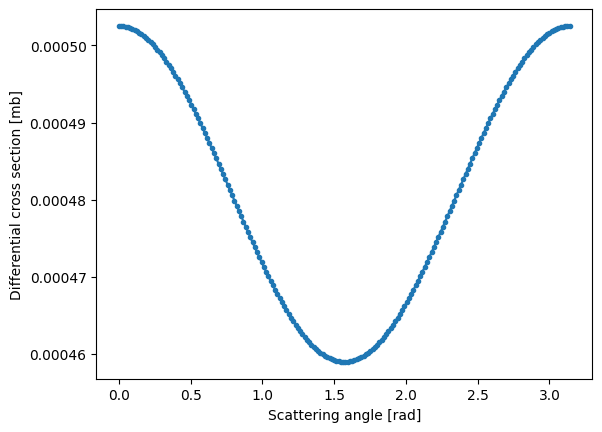

In [3]:
mass_e = 0.00051099895069 # GeV
mass_mu = 0.1056583755 # GeV
alpha = 1/137
conversion_factor = 0.3894      # this is equal to (hbar * c)^2 expressed in mbarn * GeV


def cross_section(s, theta):
    ratio = 4 * mass_mu**2 / s
    return ((np.pi * alpha**2 )/ (2 * s)) * np.sqrt(1 - ratio) * (1 + ratio + (1 - ratio) * np.cos(theta)**2)

def cross_section_norm(s, cos):     # check normalization
    ratio = 4 * mass_mu**2 / s
    beta = np.sqrt(1 - ratio)
    return 3 * (1 + cos**2 + (1 - beta**2) * (1 - cos**2)) / (4*(3 - beta**2))

E_threshold = 2*mass_mu     # threshold
print('Threshold sqrt(s) is:', E_threshold, 'GeV')
E_percent_increase = 0.1
E_fixed = E_threshold * (1 + E_percent_increase)    # should be greater than 4 mass_mu**2
print('sqrt(s) fixed at:', E_fixed, 'GeV, ', E_percent_increase * 100, r'% above threshold')
s = E_fixed**2

beam_energy = (s - 2 * mass_e**2) / (2 * mass_e)
print('Beam energy: ', beam_energy, 'GeV')

l = np.linspace(0, np.pi, 200, endpoint=True)
plt.plot(l, cross_section(s, l) * conversion_factor, marker=".")
plt.xlabel('Scattering angle [rad]')
plt.ylabel('Differential cross section [mb]')
plt.show

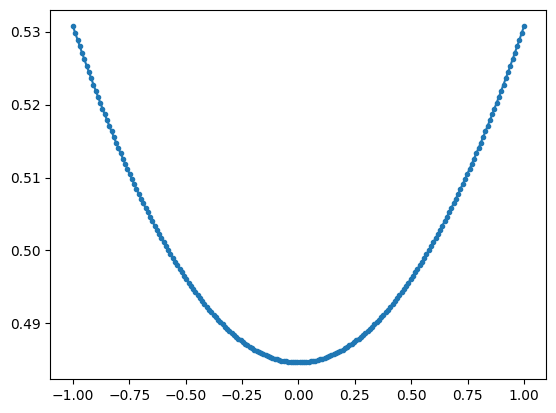

In [4]:
cos_linspace = np.linspace(-1, 1, 200, endpoint=True)
plt.plot(cos_linspace, cross_section_norm(s, cos_linspace), marker=".")


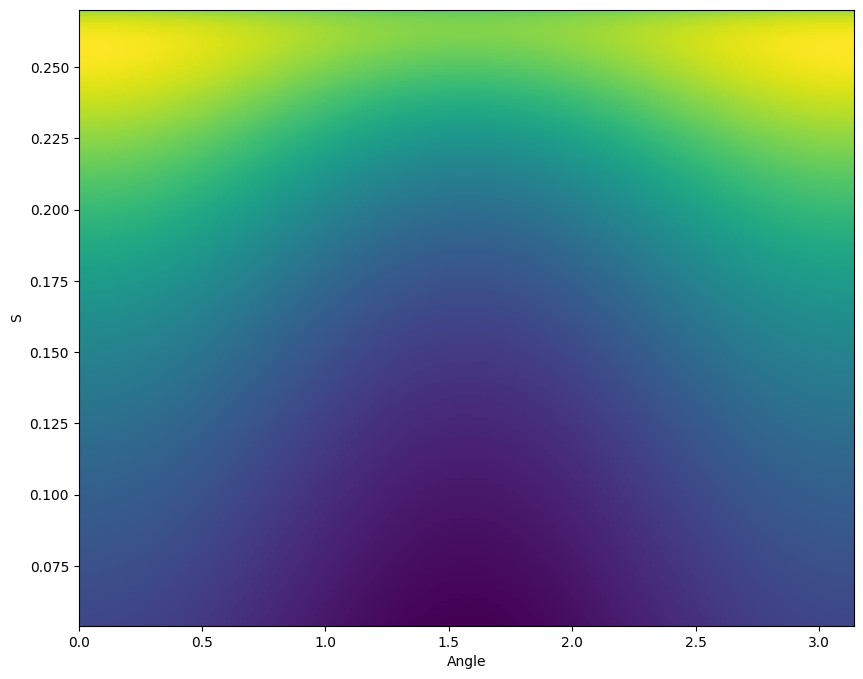

In [5]:
s_space = np.linspace(s, 5 * s, 200, endpoint=True)

xv, yv = np.meshgrid(l, s_space)

plt.figure(figsize=(10, 8))
plt.imshow(cross_section(yv, xv), extent=[0, np.pi, s, 5*s], aspect='auto')
plt.xlabel("Angle")
plt.ylabel("S")
plt.show()

94180


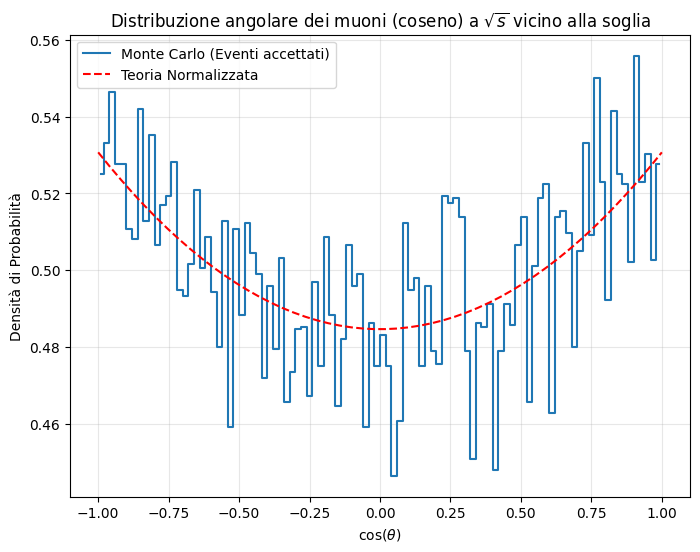

In [6]:
n = 100000
u = np.random.uniform(-1, 1, n)
r = np.random.uniform(0, cross_section_norm(s, 1), n)
v = u[r < cross_section_norm(s, u)]
print(len(v))

# Plot di confronto
plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
cos_range = np.linspace(-1, 1, 50)
plt.plot(cos_range, cross_section_norm(s, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

$ E_{e^+}=\frac{s-2m_e^2}{2m_e}$

$p_{e^+}=\sqrt{E_{e^+}^2-m_e^2}$

$\beta=\frac{p_{e^+}}{E_{e^+}+m_e}=\frac{v}{c}$

$\gamma=\frac{E_{e^+}+m_e}{\sqrt {s}}=\frac{1}{\sqrt{1-\beta^2}}$

$p_{\mu}=\sqrt{\frac{s}{4}-m_{\mu}^2}$

$p_{x,CM}=p_{\mu}\sin\theta\cos\phi$

$p_{y,CM}=p_{\mu}\sin\theta\sin\phi$

$p_{z,CM}=p_{\mu}\cos\theta$

$E_{CM}=\frac{\sqrt{s}}{2}$

$ E_{lab} = \gamma (E_{CM}+\beta p_{z,CM})$

$ p_{z,lab} = \gamma(p_{z,CM}+\beta E_{CM})$

$ p_{x,lab} = p_{x,CM}$

$ p_{y,lab} = p_{y,CM}$

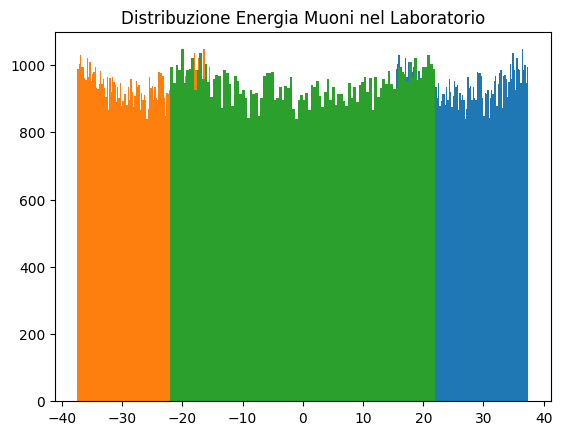

In [7]:
E_pos = (s - 2 * mass_e**2) / (2 * mass_e)
p_pos = np.sqrt(E_pos**2 - mass_e**2)
gamma = (E_pos + mass_e) / np.sqrt(s)
beta = p_pos / (E_pos + mass_e)

phi = np.random.uniform(0, 2*np.pi, len(v))
p_mod = np.sqrt(s/4 - mass_mu**2)
px_cm_1 = p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_1 = p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_1 = p_mod * v
E_cm_1 = np.sqrt(s)/2

px_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.cos(phi)
py_cm_2 = -1 * p_mod * np.sqrt(1 - v**2) * np.sin(phi)
pz_cm_2 = -1 * p_mod * v
E_cm_2 = np.sqrt(s)/2

px_lab_1=px_cm_1
py_lab_1=py_cm_1
pz_lab_1 = gamma * (pz_cm_1 + beta * E_cm_1)
E_lab_1 = gamma * (E_cm_1 + beta * pz_cm_1)

px_lab_2=px_cm_2
py_lab_2=py_cm_2
pz_lab_2 = gamma * (pz_cm_2 + beta * E_cm_2)
E_lab_2 = gamma * (E_cm_2 + beta * pz_cm_2)

plt.hist(E_lab_1, bins=100)
plt.hist(-1.0* E_lab_2, bins=100)
plt.hist(E_lab_2 - E_lab_1, bins=100)
#plt.scatter(E_lab_1, E_lab_2, marker=".")
plt.title("Distribuzione Energia Muoni nel Laboratorio")
plt.show()


(array([  189.,   514.,   899.,  1213.,  1608.,  1950.,  2268.,  2592.,
         3026.,  3318.,  3612.,  3967.,  4323.,  4683.,  5146.,  5906.,
         6719.,  7905., 10188., 24154.]),
 array([4.15408456e-06, 1.04687677e-04, 2.05221270e-04, 3.05754862e-04,
        4.06288455e-04, 5.06822048e-04, 6.07355640e-04, 7.07889233e-04,
        8.08422825e-04, 9.08956418e-04, 1.00949001e-03, 1.11002360e-03,
        1.21055720e-03, 1.31109079e-03, 1.41162438e-03, 1.51215797e-03,
        1.61269157e-03, 1.71322516e-03, 1.81375875e-03, 1.91429234e-03,
        2.01482594e-03]),
 <BarContainer object of 20 artists>)

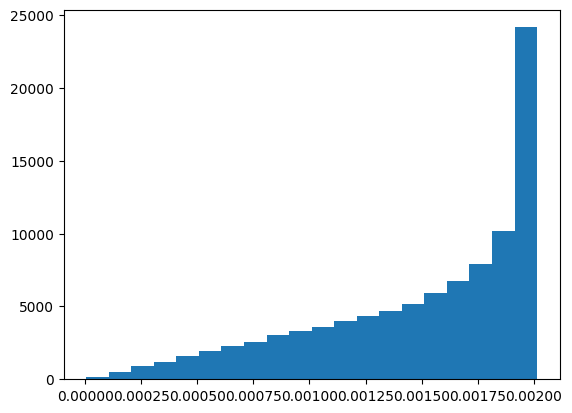

In [8]:
plt.hist(np.arccos(pz_lab_1 / np.sqrt(px_cm_1 ** 2 + py_cm_1 ** 2 + pz_lab_1 ** 2)), bins=20)

(array([  193.,   569.,   868.,  1300.,  1601.,  1932.,  2229.,  2628.,
         2922.,  3287.,  3629.,  3923.,  4318.,  4808.,  5217.,  5719.,
         6698.,  8001., 10019., 24319.]),
 array([7.11983969e-06, 1.07505145e-04, 2.07890449e-04, 3.08275754e-04,
        4.08661059e-04, 5.09046364e-04, 6.09431669e-04, 7.09816974e-04,
        8.10202279e-04, 9.10587583e-04, 1.01097289e-03, 1.11135819e-03,
        1.21174350e-03, 1.31212880e-03, 1.41251411e-03, 1.51289941e-03,
        1.61328472e-03, 1.71367002e-03, 1.81405533e-03, 1.91444063e-03,
        2.01482594e-03]),
 <BarContainer object of 20 artists>)

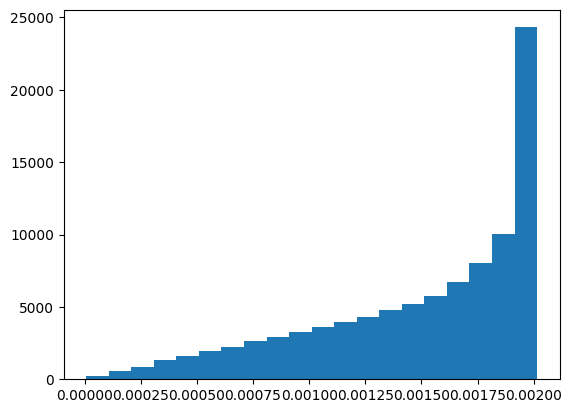

In [9]:
plt.hist(np.arccos(pz_lab_2 / np.sqrt(px_cm_2 ** 2 + py_cm_2 ** 2 + pz_lab_2 ** 2)), bins=20)

In [10]:
data = np.column_stack([E_lab_1, px_lab_1, py_lab_1, pz_lab_1, E_lab_2, px_lab_2, py_lab_2, pz_lab_2])

np.savetxt("muons_lab.txt", data)

column_names = ["E_mu+_lab", "px_mu+_lab", "py_mu+_lab", "pz_mu+_lab", "E_mu-_lab", "px_mu-_lab", "py_mu-_lab", "pz_mu-_lab"]
df = pd.read_csv("muons_lab.txt",sep=r'\s+', names=column_names)

df

,E_mu+_lab,px_mu+_lab,py_mu+_lab,pz_mu+_lab,E_mu-_lab,px_mu-_lab,py_mu-_lab,pz_mu-_lab
0,21.444331,0.005384,0.042825,21.444028,31.424927,-0.005384,-0.042825,31.424719
1,36.195861,0.001911,-0.022335,36.195699,16.673398,-0.001911,0.022335,16.673048
2,34.339976,0.032081,0.010348,34.339797,18.529282,-0.032081,-0.010348,18.528951
3,30.360643,0.045073,-0.003851,30.360425,22.508615,-0.045073,0.003851,22.508322
4,15.798615,-0.011609,0.004774,15.798257,37.070643,0.011609,-0.004774,37.070490
...,...,...,...,...,...,...,...,...
94175,15.478001,-0.004867,0.000213,15.477639,37.391257,0.004867,-0.000213,37.391108
94176,33.680482,-0.020744,-0.029985,33.680296,19.188776,0.020744,0.029985,19.188451
94177,19.009897,0.019903,0.029708,19.009570,33.859361,-0.019903,-0.029708,33.859177
94178,21.900121,-0.036766,-0.024396,21.899821,30.969137,0.036766,0.024396,30.968926


Text(0, 0.5, '$\\phi$ [rad]')

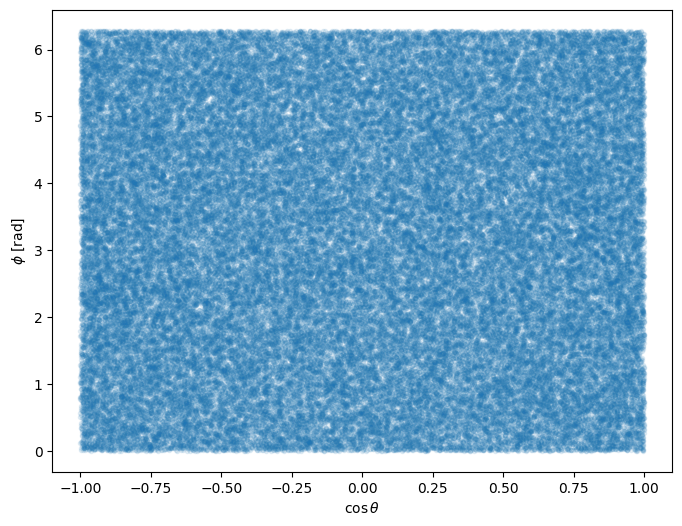

In [11]:
plt.figure(figsize=(8, 6))

plt.scatter(v, phi, marker=".", alpha=0.1)
plt.xlabel(r"$\cos{\theta}$")
plt.ylabel(r"$\phi$ [rad]")

Text(0, 0.5, '$\\phi$ [rad]')

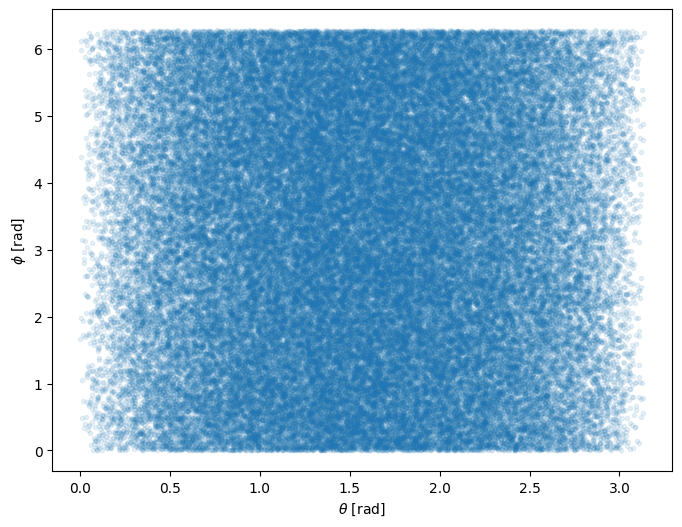

In [12]:
plt.figure(figsize=(8, 6))

plt.scatter(np.arccos(v), phi, marker=".", alpha=0.1)
plt.xlabel(r"$\theta$ [rad]")
plt.ylabel(r"$\phi$ [rad]")

In [13]:
#total cross section integrating over solid angle
cross_section_tot = ((2 * np.pi * alpha**2) / (3 * s)) * beta * (3 - beta**2) * conversion_factor
print('The total cross section is:', cross_section_tot, 'mbarn')

The total cross section is: 0.0016083856965234868 mbarn


In [14]:
# point 6
d = 3                       # cm
rate = 10**6                # Hz

uma = 1.660539e-24          # unitò di massa atomica in g
B = 9.0121831               # atomic weight del berillio in uma
rho = 1.845                 # densità del berillio in g/cm^3
n_be = rho / (uma * B)         # densità atomica del berillio

P = n_be * d * cross_section_tot * 10**(-27)       # convertendo la cross section da mbarn a cm**2
T = 7 * 24 * 3600           # s

E = T * rate * P
weight = E / len(v)
print(E)
print(len(v))

print('The conversion factor is:', weight)

359782.90427444497
94180
The conversion factor is: 3.820162500259556


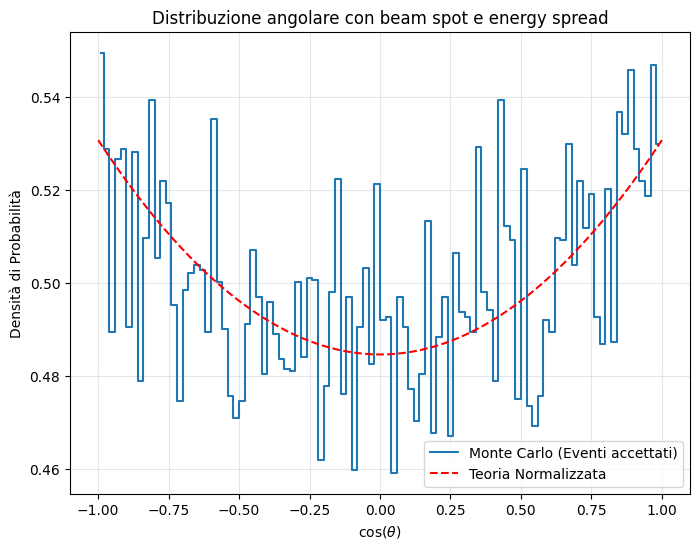

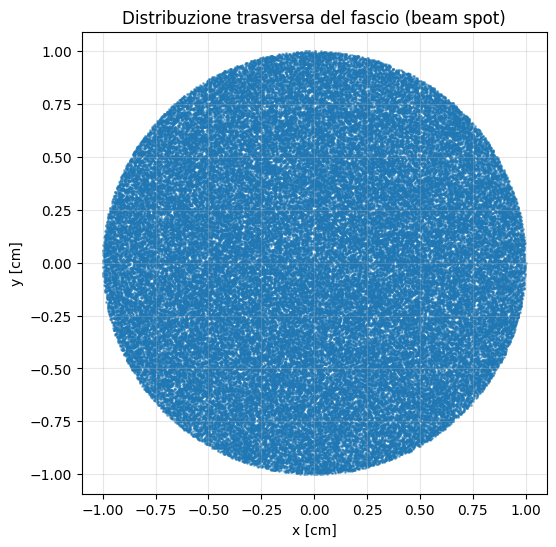

In [15]:
R = 1.0  
alpha = np.random.uniform(0, 2*np.pi, n)
rho = R * np.sqrt(np.random.uniform(0,1,n))
x = rho * np.cos(alpha)
y = rho * np.sin(alpha)

sigmaE=0.5 #width
E=np.random.normal(beam_energy, sigmaE, n)

m_e = 0.000511  # GeV
s = 2 * m_e * (E + m_e) #in lab frame

u_new = np.random.uniform(-1, 1, n)
r_new = np.random.uniform(0, cross_section_norm(s, 1), n)
v_new = u_new[r_new < cross_section_norm(s, u_new)]


# Plot di confronto
plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v_new, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
s_mean = np.mean(s)#curva teorica “di riferimento”, confronto visivo con la curva teorica serve una singola curva
cos_range = np.linspace(-1, 1, 100)
plt.plot(cos_range, cross_section_norm(s_mean, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare con beam spot e energy spread")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot del beam spot (x,y)
plt.figure(figsize=(6,6))
plt.scatter(x, y, s=1, alpha=0.5)
plt.xlabel("x [cm]")
plt.ylabel("y [cm]")
plt.title("Distribuzione trasversa del fascio (beam spot)")
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Energia soglia per generare muoni
E_th = ((2*mass_mu)**2 - 2 * m_e**2) / (2*m_e)  # GeV

# Parametri target
L = 6.0   # lunghezza target in cm (usato nel paper del prof)
X0 = 35.3 # lunghezza di radiazione del Be in cm
E0 = E_th * np.exp(L / X0)
print(f"Nominal beam energy: {E0:.2f} GeV")

z = np.random.uniform(0, L, n)  # posizione casuale lungo il target
E_beam = E0 * np.exp(-z / X0)  # energia effettiva al punto z

data = pd.DataFrame({"x_cm": x,"y_cm": y, "z_cm": z,"E_beam_GeV": E_beam})
data.to_csv("simulated_muon_beam.csv", index=False)
data

Nominal beam energy: 51.79 GeV


,x_cm,y_cm,z_cm,E_beam_GeV
0,-0.040613,-0.792405,4.639611,45.409705
1,-0.124505,-0.594784,0.414921,51.182899
2,0.548988,-0.664267,0.370681,51.247084
3,0.384973,0.626297,2.373086,48.420989
4,-0.493046,-0.134540,0.974862,50.377422
...,...,...,...,...
99995,0.726143,-0.113615,0.252238,51.419323
99996,0.785223,0.614126,1.044077,50.278741
99997,-0.797294,-0.367871,2.573170,48.147310
99998,-0.233037,0.555799,1.899132,49.075495


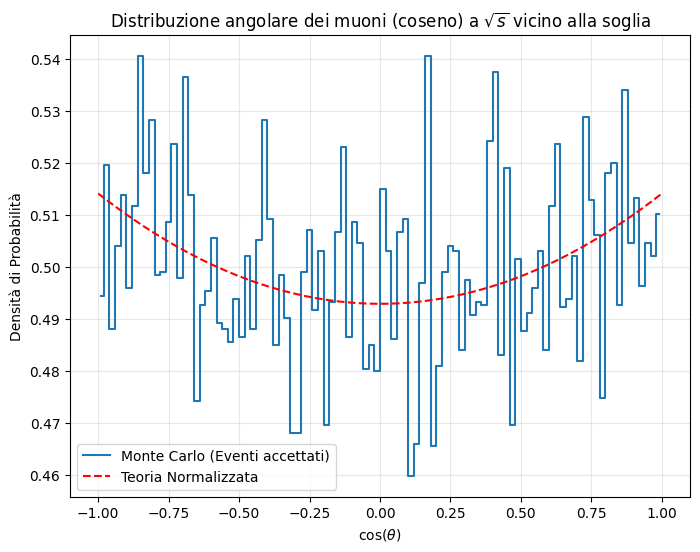

In [17]:
# Genera angoli nel CM usando s_z
s_z = 2 * m_e**2 + 2 * m_e * E_beam

u_z = np.random.uniform(-1, 1, n)
r_z = np.random.uniform(0, cross_section_norm(s_z, 1), n)
v_z = u_z[r_z < cross_section_norm(s_z, u_z)]

plt.figure(figsize=(8, 6))

# Istogramma del Monte Carlo (Normalizzato con density=True)
hist, bin_edges = np.histogram(v_z, bins=100, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.
plt.step(bin_centers, hist, where='mid', label="Monte Carlo (Eventi accettati)")

# Curva teorica normalizzata
s_z_mean = np.mean(s_z)
cos_range = np.linspace(-1, 1, 50)
plt.plot(cos_range, cross_section_norm(s_z_mean, cos_range), 'r--', label="Teoria Normalizzata")

plt.xlabel(r"$\cos(\theta)$")
plt.ylabel("Densità di Probabilità")
plt.title(r"Distribuzione angolare dei muoni (coseno) a $\sqrt{s}$ vicino alla soglia")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Effettua il Boost nel Lab usando E_z e s_z

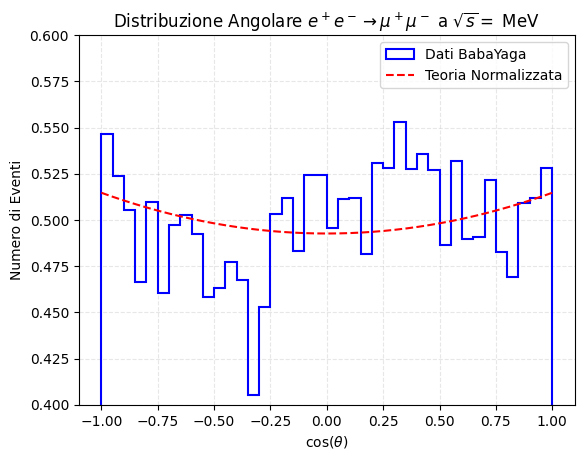

In [31]:
def distr_rel(beta, cos):
    return 3 * (2 - beta**2 + ( beta**2) * cos**2) / (4 * (3 - beta**2))

def plot_angular_distribution(file_path, sqrt_s):
    cos_theta_list = []
    weights_list = []
    
    with open(file_path, 'r') as f:
        lines = f.readlines()
        
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith('# EVENT N.'):
            weights_list.append(float(lines[i+1].strip()))
            n_particles = int(lines[i+2].strip())
            
            # Leggiamo il primo muone (solitamente la riga i+3)
            # Formato riga: E px py pz
            muon_data = lines[i+3].split()
            pz = float(muon_data[3])
            energy = float(muon_data[0])
            
            # Calcolo cos(theta) = pz / |p|
            # Per muoni ultra-relativistici |p| approx E, 
            # altrimenti usiamo la norma del vettore p_x, p_y, p_z
            px = float(muon_data[1])
            py = float(muon_data[2])
            p_norm = np.sqrt(px**2 + py**2 + pz**2)
            
            if p_norm > 0:
                cos_theta_list.append(pz / p_norm)
            
            # Salta al prossimo evento
            i += 3 + n_particles
        else:
            i += 1

    # 1. Disegna l'istogramma e salva i valori dei bin
    counts, bins, _ = plt.hist(cos_theta_list, bins=40, density=True, weights=weights_list, range=(-1, 1), 
                               histtype='step', color='blue', label='Dati BabaYaga', linewidth=1.5)

    x_theory = np.linspace(-1, 1, 200)
    y_theory = cross_section_norm(sqrt_s**2, x_theory)
    plt.plot(x_theory, y_theory, 'r--', label="Teoria Normalizzata")
    #plt.plot(x_theory, distr_rel(0.01, x_theory), 'r--', color='green', label="Distr")

    
    # Normalizzazione della teoria per sovrapporla ai conteggi medi
    #avg_counts = np.mean(counts)
    #avg_theory = (2 - beta_sq) + (beta_sq / 3) # Media integrale di 2-b^2 + b^2*x^2 su [-1,1]
    #y_theory_norm = y_theory * (avg_counts / avg_theory)
    
    #plt.plot(x_theory, y_theory_norm, 'r--', label='Teoria Born (Normalizzata)', linewidth=2)


    plt.title(r'Distribuzione Angolare $e^+ e^- \to \mu^+ \mu^-$ a $\sqrt{s}=$ MeV')
    plt.xlabel(r'$\cos(\theta)$')
    plt.ylabel('Numero di Eventi')
    plt.ylim((0.4,0.6))
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend()
    
    plt.show()
# Esegui lo script sul tuo file
plot_angular_distribution('ResultsBabaYaga/run_221_tree/events.dat', sqrt_s=0.221)

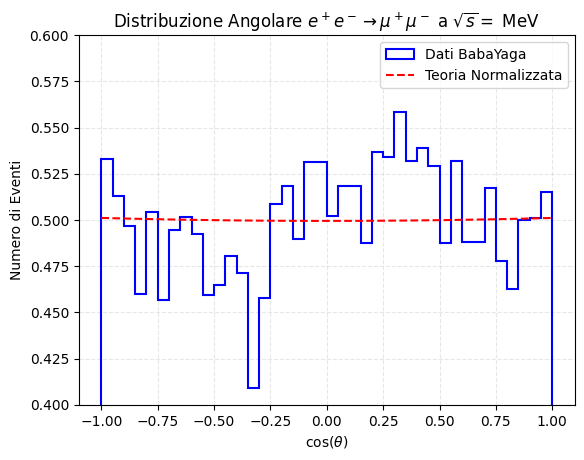

In [32]:
plot_angular_distribution('ResultsBabaYaga/run_212_tree/events.dat', sqrt_s=0.212)